# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "xgb"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'mlruns/351026250497371967/78f8f2cda9cb40fd9c94955ba50af36d/artifacts/probabilities/xgb/xgb_pivot_summary.csv'

## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.364865,0.283891,74
1,219.5,0.208333,0.216170,72
2,220.5,0.276316,0.253025,76
3,221.5,0.172414,0.204549,58
4,222.5,0.270270,0.189334,74
5,223.5,0.108108,0.164062,74
6,224.5,0.242857,0.165244,70
7,225.5,0.222222,0.154663,81
8,226.5,0.146667,0.158021,75
9,227.5,0.207792,0.179081,77


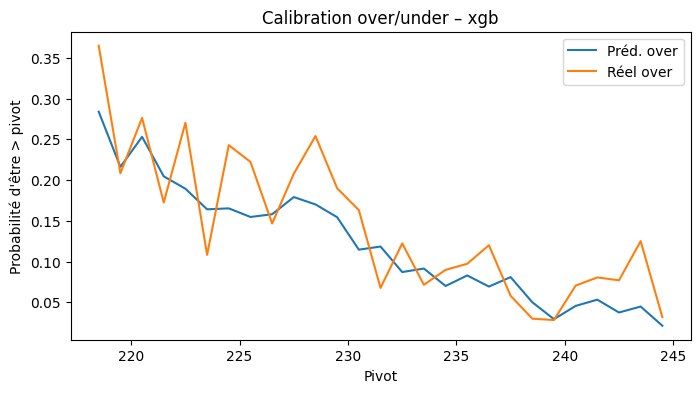

In [ ]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [ ]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
1480,177.93689,162,240.5,1.048051e-13,1.0,0.5,True
810,175.29575,158,241.5,1.921185e-11,1.0,0.5,True
656,188.76299,188,244.5,9.146017e-11,1.0,0.5,True
15,179.10402,171,236.5,1.214925e-10,1.0,0.5,True
1412,181.63419,189,240.5,1.666984e-10,1.0,0.5,True
1889,173.89368,161,234.5,3.281646e-10,1.0,0.5,True
1581,179.35048,175,231.5,4.430292e-10,1.0,0.5,True
1634,179.75603,178,244.5,4.590717e-10,1.0,0.5,True
783,183.82320,191,243.5,8.204830e-10,1.0,0.5,True
800,177.59427,179,244.5,1.221468e-09,1.0,0.5,True


## Pivot bins (2 pts)

/tmp/ipykernel_2436385/2097160386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 220.5)",146,0.287671,0.250494
1,"[220.5, 222.5)",134,0.231343,0.232043
2,"[222.5, 224.5)",148,0.189189,0.176698
3,"[224.5, 226.5)",151,0.231788,0.159568
4,"[226.5, 228.5)",152,0.177632,0.168690
5,"[228.5, 230.5)",142,0.218310,0.161315
6,"[230.5, 232.5)",166,0.120482,0.116243
7,"[232.5, 234.5)",174,0.097701,0.089139
8,"[234.5, 236.5)",150,0.093333,0.076162
9,"[236.5, 238.5)",144,0.090278,0.074810


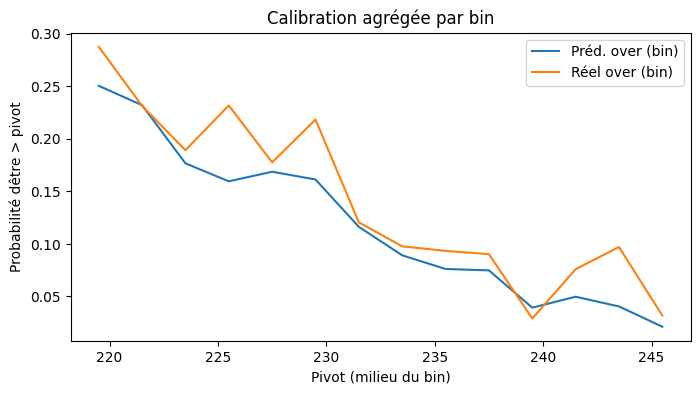

In [ ]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=2, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [ ]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,1934,0.887797
1,0.10,1880,0.896277
2,0.15,1829,0.901039
3,0.20,1759,0.911313
4,0.25,1699,0.919364


## Distribution des sigma

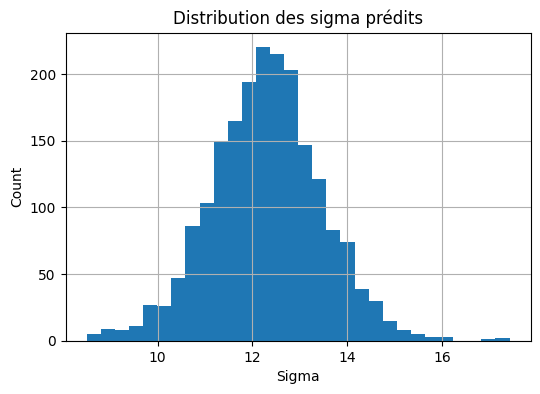

In [ ]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
